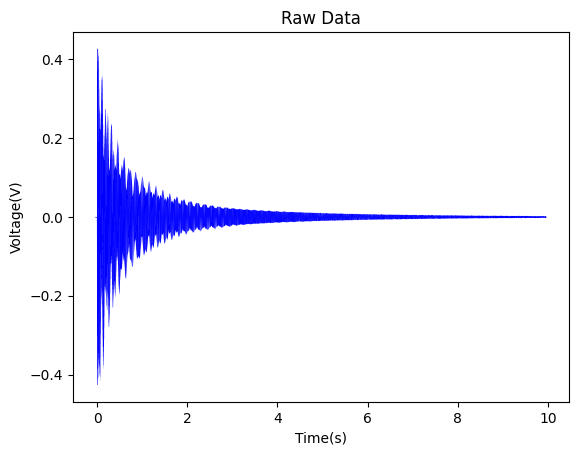

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import ipywidgets as widgets
from IPython.display import display

data = np.loadtxt("usr_wf_C1_data.csv",skiprows = 12, delimiter = ",")
data2 = np.loadtxt("usr_wf_C4_data.csv",skiprows = 12, delimiter = ",")
data3 = np.loadtxt("usr_wf_F1_data.csv",skiprows = 12, delimiter = ",")

t = data[12:,0]
V = data[12:,1]

f = data3[12:,0]
A = data3[12:,3]

#raw data

plt.figure()
plt.title("Raw Data")

plt.plot(t, V, 'b-', linewidth = 0.05)

plt.xlabel("Time(s)")
plt.ylabel("Voltage(V)")

plt.show()

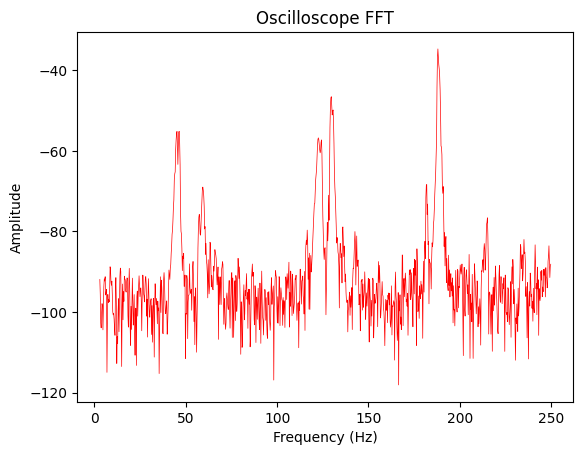

In [2]:

#fft oscilloscope

plt.figure()
plt.title("Oscilloscope FFT")

plt.plot(f, A, 'r-', linewidth = 0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.show()

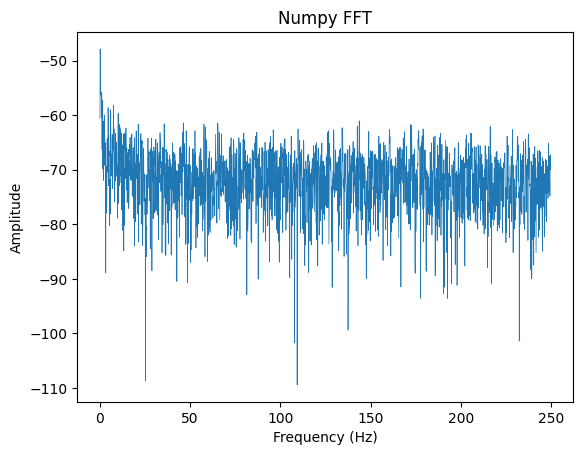

In [3]:
V_centered = V - np.mean(V)

N = len(V)
dt = np.mean(np.diff(t))
fs = 1/dt

window = np.hanning(N)
V_windowed = V_centered * window
fft_result = np.fft.rfft(V_windowed)

# Frequency bins corresponding to the FFT output
freqs = np.fft.rfftfreq(len(V), d=1/fs)

# Magnitude spectrum
magnitude = np.abs(fft_result)/N
magnitude[1:-1] *= 2
magnitude_db = 20*np.log10(magnitude/np.max(magnitude))

mask = freqs <= 250

#fft numpy

plt.figure()
plt.title("Numpy FFT")

plt.plot(freqs[mask], magnitude_db[mask], linewidth = 0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.show()

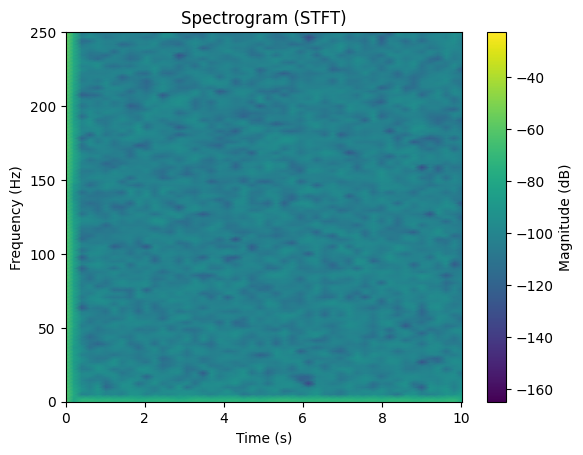

In [4]:
envelope = np.abs(V)
threshold = 0.01 * np.max(envelope)
cutoff_index = np.where(envelope > threshold)[0][-1]

V_crop = V[:cutoff_index]
t_crop = t[:cutoff_index]

# Using your full signal (V, fs) — decaying oscillation
f, t_stft, Zxx = stft(V, fs=fs, window='hann', nperseg=2048*2, noverlap=1024*2)

magnitude_db = 20*np.log10(np.abs(Zxx) + 1e-12)

plt.figure()
plt.pcolormesh(t_stft, f, magnitude_db, shading='gouraud', cmap='viridis')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.ylim(0, 250)  # match your frequency range of interest
plt.colorbar(label='Magnitude (dB)')
plt.title('Spectrogram (STFT)')
plt.show()

interactive(children=(IntSlider(value=0, description='Frame', max=49), Output()), _dom_classes=('widget-intera…

<function __main__.plot_frame(frame)>

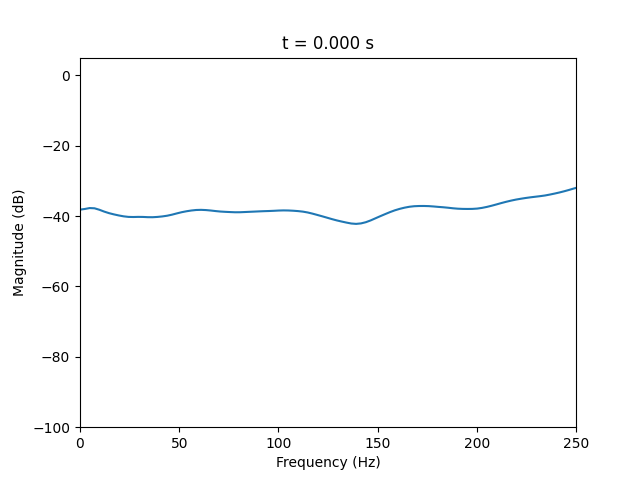

In [5]:
%matplotlib widget

magnitude_db = 20*np.log10(np.abs(Zxx) / np.max(np.abs(Zxx)) + 1e-12)

fig, ax = plt.subplots()
line, = ax.plot(f, magnitude_db[:, 0])
ax.set_xlim(0, 250)
ax.set_ylim(-100, 5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
title = ax.set_title('')

def plot_frame(frame):
    line.set_ydata(magnitude_db[:, frame])
    title.set_text(f't = {t_stft[frame]:.3f} s')
    fig.canvas.draw_idle()

slider = widgets.IntSlider(min=0, max=magnitude_db.shape[1]-1, step=1, value=0, description='Frame')
widgets.interact(plot_frame, frame=slider)